In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
Data=pd.read_csv("linear_regression_dataset.csv")
Data.head()

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754


In [26]:
print(Data.info())
Data=Data.dropna()
print((Data.isnull().sum()*100/(Data.shape[0])).sort_values())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     500 non-null    int64  
 1   FEMALE  500 non-null    int64  
 2   LOS     500 non-null    int64  
 3   RACE    499 non-null    float64
 4   TOTCHG  500 non-null    int64  
 5   APRDRG  500 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 23.6 KB
None
AGE       0.0
FEMALE    0.0
LOS       0.0
RACE      0.0
TOTCHG    0.0
APRDRG    0.0
dtype: float64


In [27]:
Y=Data["TOTCHG"]
X=Data.drop(columns="TOTCHG")
Y.head(),X.head()

(0     2660
 1     1689
 2    20060
 3      736
 4     1194
 Name: TOTCHG, dtype: int64,
    AGE  FEMALE  LOS  RACE  APRDRG
 0   17       1    2   1.0     560
 1   17       0    2   1.0     753
 2   17       1    7   1.0     930
 3   17       1    1   1.0     758
 4   17       1    1   1.0     754)

In [28]:
def train_test_split(X, Y, test_ratio=0.8, seed=None):
    if seed :
        np.random.seed(seed)
        
    m = len(X)
    indices = np.random.permutation(m)
    test_size = int(test_ratio * m)
    test_idx = indices[test_size:]
    train_idx = indices[:test_size]

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    Y_train = Y.iloc[train_idx]
    Y_test  = Y.iloc[test_idx]

    return X_train, X_test, Y_train, Y_test

X1 , X2 , Y1 , Y2 = train_test_split(X,Y,seed=5335)
X1 = X1.copy()
X2 = X2.copy()
Y1=np.array(Y1).reshape(-1,1)

Y2=np.array(Y2).reshape(-1,1)



In [29]:
#Standardisation
def Standardize(X1,X2):
    dummy_cols=[col for col in X1.columns if set(X1[col].unique()).issubset({0,1})]
    num_cols=[col for col in X1.columns if col not in dummy_cols]
    mean=X1[num_cols].mean()
    std=X1[num_cols].std()

    X1[num_cols]=(X1[num_cols]-mean)/std
    X2[num_cols]=(X2[num_cols]-mean)/std
    X1[dummy_cols]=X1[dummy_cols]
    X2[dummy_cols]=X2[dummy_cols]
Standardize(X1,X2)

X1.head()


,AGE,FEMALE,LOS,RACE,APRDRG
455,-0.738121,0,0.106119,-0.154353,0.111901
452,1.278086,1,0.456047,-0.154353,-0.342990
491,-0.738121,0,-0.243810,-0.154353,0.111901
180,-0.738121,0,0.456047,-0.154353,0.111901
249,-0.738121,1,-0.243810,-0.154353,0.111901


In [30]:
#Regression Code
def predict(X,W,b):
    return X@W+b
def mse(Y_pred,Y):
    return np.mean((Y_pred-Y)**2)

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    return 1 - ss_res / ss_tot

def compute_gradient(X,Y,W,b):
    n=X.shape[0]
    Y_pred=predict(X,W,b)
    E=Y_pred-Y
    dW=(2/n)*X.T@E
    db=(2/n)*sum(E)
    return dW,db
def update(W,b,dW,db,lr):
    W=W-lr*dW
    b=b-lr*db
    return W,b

def train(X,Y,lr=0.01,epochs=1000,I_O=0):
    X=np.array(X)
    Y=np.array(Y).reshape(-1,1)
    m=X.shape[1]
    W=np.zeros((m,1))
    b=0.0
    losses = []
    for i in range(epochs):
        dW,db=compute_gradient(X,Y,W,b)
        W,b=update(W,b,dW,db,lr)
        Y_pred = predict(X ,W, b)
        loss = mse(Y, Y_pred)
        losses.append(loss)
        if I_O==0:
            continue
        if i%100==0:
            Y2_pred = predict(X2, W, b)
            test_mse = mse(Y2, Y2_pred)
            test_rmse=np.sqrt(test_mse)
            train_rmse = np.sqrt(loss)
            test_rmse = np.sqrt(test_mse)
            rel_error_train = np.abs(Y1 - Y_pred) / np.abs(Y1)
            rel_error_test = np.abs(Y2 - Y2_pred) / np.abs(Y2)

            mean_rel_error_train_error = np.mean(rel_error_train)
            mean_rel_error_test_error = np.mean(rel_error_test)
            print("Train RMSE:", train_rmse)
            print("Test RMSE:", test_rmse)

            print("Mean Relative Train Error (%):", mean_rel_error_train_error * 100)
            print("Mean Relative Test Error (%):", mean_rel_error_test_error * 100)

            print("train r2 score:",r2_score(Y,Y_pred))
            print("test r2 score:",r2_score(Y2,Y2_pred))


    return W,b,losses


In [31]:
W,b,losses=train(X1,Y1,epochs=1000,I_O=1)


Train RMSE: 3942.7395272248627
Test RMSE: 6972.907917032944
Mean Relative Train Error (%): 96.74938982469997
Mean Relative Test Error (%): 96.75827458458001
train r2 score: -0.6606505451780114
test r2 score: -0.30009608656695286
Train RMSE: 1854.9903642743582
Test RMSE: 4775.405823032358
Mean Relative Train Error (%): 37.30272395409447
Mean Relative Test Error (%): 38.45895972685049
train r2 score: 0.6324085555658965
test r2 score: 0.39022704234006955
Train RMSE: 1765.8525869991302
Test RMSE: 4700.732231814476
Mean Relative Train Error (%): 37.0553750402503
Mean Relative Test Error (%): 39.66462658150768
train r2 score: 0.6668874687161614
test r2 score: 0.4091481260962462
Train RMSE: 1747.7861378445464
Test RMSE: 4689.150880326292
Mean Relative Train Error (%): 35.05567189744214
Mean Relative Test Error (%): 38.557989600304694
train r2 score: 0.6736687535565387
test r2 score: 0.4120559427496514
Train RMSE: 1739.3300086143752
Test RMSE: 4684.153786835256
Mean Relative Train Error (%): 3

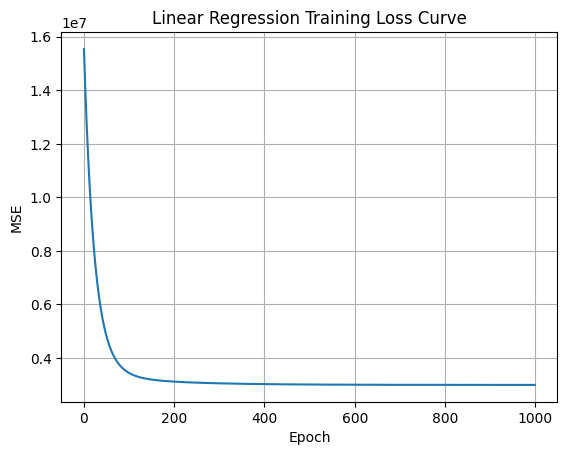

In [32]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Linear Regression Training Loss Curve")
plt.grid(True)
plt.show()


In [33]:
Y2_pred = predict(X2, W, b)
test_mse = mse(Y2, Y2_pred)
train_mse = losses[-1]
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
rel_error = np.abs(Y2 - Y2_pred) / np.abs(Y2)
mean_rel_error = np.mean(rel_error)
print("Final Train MSE:", train_mse)
print("Test MSE:", test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Mean Relative Error (%):", mean_rel_error * 100)
Y_pred=predict(X1,W,b)
print("train r2 score:",r2_score(Y1,Y_pred))
print("test r2 score:",r2_score(Y2,Y2_pred))



Final Train MSE: 2995300.9318647888
Test MSE: 21882131.221131142
Train RMSE: 1730.6937718339395
Test RMSE: 4677.83403095184
Mean Relative Error (%): 39.5582619035079
train r2 score: 0.6800202164064313
test r2 score: 0.41489041981381247


In [34]:
X_np = X1.values
cond_number = np.linalg.cond(X_np.T @ X_np)
print("Condition number:", cond_number)


Condition number: 2.6444025098031827


In [35]:
#Comparing to least squares solution

## Intercept column
Xb_train = np.c_[np.ones((X1.shape[0], 1)), X1.values]
Xb_test  = np.c_[np.ones((X2.shape[0], 1)), X2.values]

beta_closed = np.linalg.inv(Xb_train.T @ Xb_train) @ Xb_train.T @ Y1

b_closed = beta_closed[0]
W_closed = beta_closed[1:]


Y2_pred_closed = Xb_test @ beta_closed

mse_closed = np.mean((Y2 - Y2_pred_closed)**2)
rmse_closed = np.sqrt(mse_closed)
 
print("Closed-form Test MSE:", mse_closed)
print("Closed-form Test RMSE:", rmse_closed)
print("Closed-form abs error:", 100*np.mean(np.abs(Y2_pred_closed-Y2)/Y2))
print("Closed-form Test r2 score:",r2_score(Y2,Y2_pred_closed))




Closed-form Test MSE: 21877176.22005151
Closed-form Test RMSE: 4677.30437539097
Closed-form abs error: 39.944052294178945
Closed-form Test r2 score: 0.41502291232892585


In [36]:
print("Closed:")
print(W_closed.ravel(),b_closed)
print("Gradient descent:")
print(W.ravel(),b)

Closed:
[  810.22196831  -377.7238249   2062.23826169  -143.22119492
 -1426.12076377] [2785.04063316]
Gradient descent:
[  805.25438998  -329.6835311   2062.60324492  -142.80800948
 -1432.8035648 ] [2755.81261306]
